# NumPy Hands-on Lab: From Arrays to Image Analysis

## Student Practice Notebook

**Name:** MONIKA DEVI BANDARU
**Register Number:** AP24110011073  
**Date:**14TH AUG

## Learning Objectives

After completing this lab, you will be able to:

- Create and manipulate NumPy arrays
- Understand array properties and dimensions
- Perform indexing and slicing
- Apply mathematical operations
- Understand and explain broadcasting
- Analyze images using NumPy arrays
- Perform basic image transformations
- Explain *why* NumPy is used in real ML/Data Science pipelines, not just *how*

### How to use this notebook
- **Demonstration** cells: run them, read the output, understand it.
- **Practice** cells: write your own code — don't copy the demo verbatim.
- **Predict-then-run**: before running some cells, you'll be asked to *predict* the output first. Write your prediction in the markdown cell, then run and compare.
- **Reflection**: short written answers, in your own words.


## Part 1: Introduction to NumPy

NumPy (Numerical Python) is a Python library used for efficient numerical computation.

**Why not just use Python lists?** Python lists store objects with overhead per element and loop in pure Python. NumPy arrays store raw numbers in contiguous memory and use compiled C code for operations — this is called **vectorization**. That's why NumPy is used everywhere in:

- Data Science (pandas is built on NumPy)
- Machine Learning (feeding data into models as arrays/tensors)
- Image Processing (an image *is* a NumPy array)
- Scientific Computing

Let's actually *see* the speed difference before we take it on faith.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy is ready!")


NumPy is ready!


### Demonstration: Loops vs. Vectorization (the "why" behind NumPy)

Below we add 1 to a million numbers two ways: a plain Python loop, and a NumPy array operation.
Run this cell and look at the timing output.


In [ ]:
import time

n = 1_000_000
python_list = list(range(n))
numpy_array = np.arange(n)

start = time.time()
result_list = [x + 1 for x in python_list]
loop_time = time.time() - start

start = time.time()
result_array = numpy_array + 1
vector_time = time.time() - start

print(f"Python loop time : {loop_time:.5f} seconds")
print(f"NumPy vector time: {vector_time:.5f} seconds")
print(f"NumPy was about {loop_time/vector_time:.0f}x faster")


Python loop time : 0.09174 seconds
NumPy vector time: 0.00829 seconds
NumPy was about 11x faster


*Your answer:* The overall brightness is the mean of all pixel-channel values. The red, green, and blue brightness values are the means of their respective channels; the channel with the largest mean is the brightest for the uploaded image.


## Part 2: Creating NumPy Arrays

### Demonstration

In [ ]:
arr = np.array([10,20,30,40,50])
arr


array([10, 20, 30, 40, 50])

### Student Practice

Create an array containing:

5, 10, 15, 20, 25

Write your code below (do not just copy the demo — change the numbers yourself):

*Answer:* The code creates a one-dimensional NumPy array containing the five requested values.


In [ ]:
# AP24110011073
import numpy as np
my_array = np.array([5, 10, 15, 20, 25])
print(my_array)


## Part 3: Array Properties

Important properties:

- `ndim` : Number of dimensions
- `shape` : Size of each dimension
- `size` : Total number of elements
- `dtype` : Data type

**Predict first:** for the array `arr` from Part 2, what do you *expect* `ndim`, `shape`, `size`, and `dtype` to be? Write your guess below before running the next cell.

*Your prediction:ndim: 1,shape: (5,),size: 5,dtype: int64 or int32


In [ ]:
arr.ndim, arr.shape, arr.size, arr.dtype


(1, (5,), 5, dtype('int64'))

### Observation

Was your prediction correct? If not, what did you get wrong and why?

*Answer:* Yes. The array has 1 dimension, shape `(5,)`, size `5`, and an integer data type because it contains five integer values.


## Part 4: Special Arrays

These are commonly used to initialize data — for example, `zeros` is often used to create an empty "canvas" array before filling in real values (you'll see this again in the image section).


In [ ]:
np.zeros((3,3))


array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
np.ones((4,4))


array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [ ]:
np.eye(3)


array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### Student Practice

Create a `5x5` array of all zeros, and a `2x6` array of all ones. Write both below.

*Answer:* A `5x5` zeros array contains 25 zeros, and a `2x6` ones array contains 12 ones.


In [ ]:
zeros_5x5 = np.zeros((5, 5), dtype=int)
ones_2x6 = np.ones((2, 6), dtype=int)

print("5x5 zeros:")
print(zeros_5x5)
print("\n2x6 ones:")
print(ones_2x6)


[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
[[1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]]


## Part 5: Sequence Generation

In [ ]:
np.arange(0,50,5)


array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45])

In [ ]:
np.linspace(0,100,10)


array([  0.        ,  11.11111111,  22.22222222,  33.33333333,
        44.44444444,  55.55555556,  66.66666667,  77.77777778,
        88.88888889, 100.        ])

### Student Practice

`np.arange` and `np.linspace` both generate sequences but work differently.

1. Use `np.arange` to generate even numbers from 2 to 20.
2. Use `np.linspace` to generate 5 evenly spaced numbers between 0 and 1.
3. In one sentence, write the difference between `arange` (step-based) and `linspace` (count-based).

*Answer:* `arange` uses a step size and `linspace` uses the requested number of evenly spaced values.


In [ ]:
# AP24110011073
evens_2_to_20 = np.arange(2, 21, 2)
five_spaced_0_to_1 = np.linspace(0, 1, 5)

print("Even numbers:", evens_2_to_20)
print("5 evenly spaced numbers:", five_spaced_0_to_1)
print("arange is step-based, while linspace is count-based.")


## Part 6: Random Numbers

In [ ]:
np.random.rand(5)


array([0.72193953, 0.4211946 , 0.67325498, 0.09303422, 0.88686904])

In [ ]:
np.random.randint(1,100,10)


array([33, 37, 95, 94, 87, 99, 52, 61, 46, 53])

## Part 7: Reshaping Arrays

Reshape changes the *structure* of an array without changing the data.

**Rule: the total number of elements must stay the same.** `3x4 = 12` elements, so you can reshape into any combination of dimensions that multiplies to 12 (e.g. `2x6`, `4x3`, `1x12`, `12x1`).


In [ ]:
a = np.arange(12)
a.reshape(3,4)


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

### Student Practice — valid shapes

Try reshaping `a` into these shapes. Write each as a separate line:
- 2 x 6
- 4 x 3
- 6 x 2

*Answer:* All three shapes are valid because each contains 12 elements, the same as the original array.


In [ ]:
a = np.arange(12)
a_2x6 = a.reshape(2, 6)
a_4x3 = a.reshape(4, 3)
a_6x2 = a.reshape(6, 2)

print("2x6:\n", a_2x6)
print("\n4x3:\n", a_4x3)
print("\n6x2:\n", a_6x2)


[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
[[ 0  1]
 [ 2  3]
 [ 4  5]
 [ 6  7]
 [ 8  9]
 [10 11]]


### Student Practice — break it on purpose

Now try `a.reshape(5,3)`. This should throw an error because 5 × 3 = 15 ≠ 12.

Run it, read the error message, then answer: **why did it fail, and what rule does it confirm about reshape?**

*Your answer:* It fails because the original array has 12 elements, while a `5x3` array would need 15. Reshape can change the dimensions, but it cannot change the total number of elements.


In [ ]:
a = np.arange(12)

try:
    invalid = a.reshape(5, 3)
    print(invalid)
except ValueError as e:
    print("ValueError:", e)
    print("A reshape must keep the total number of elements unchanged: 5 x 3 = 15, but the array has 12 elements.")


[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
[[ 0  1]
 [ 2  3]
 [ 4  5]
 [ 6  7]
 [ 8  9]
 [10 11]]
[[ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]]


## Part 8: Indexing and Slicing

In [ ]:
matrix = np.arange(1,10).reshape(3,3)
matrix


array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [ ]:
# Extract first row
matrix[0]


array([1, 2, 3])

In [ ]:
# Extract first column
matrix[:,0]


array([1, 4, 7])

### Student Practice

Using `matrix` above, write code to extract:
1. The last row
2. The last column
3. The single element in the middle (row 1, column 1)
4. The bottom-right 2x2 sub-matrix

*Answer:* Use `matrix[-1]`, `matrix[:, -1]`, `matrix[1,1]`, and `matrix[-2:, -2:]` respectively.


In [ ]:
last_row = matrix[-1]
last_col = matrix[:, -1]
middle_element = matrix[1, 1]
bottom_right_2x2 = matrix[-2:, -2:]

print("Last row:", last_row)
print("Last column:", last_col)
print("Middle element:", middle_element)
print("Bottom-right 2x2:\n", bottom_right_2x2)


Last row:
 [ 8  9 10 11]
Last column:
 [ 3  7 11]
Middle element: 5
Bottom-right 2x2:
 [[ 6  7]
 [10 11]]


## Part 9: Mathematical Operations

In [ ]:
marks = np.array([60,70,80,90])

marks + 5


array([65, 75, 85, 95])

In [ ]:
marks * 2


array([120, 140, 160, 180])

### Student Practice

A student scored `marks = [55, 62, 48, 91, 73]` but every question was later found to be worth 1 extra bonus mark, and then the whole test was scaled to be out of 150 (currently out of 100, so multiply by 1.5).

Write the NumPy code to: (1) add the bonus mark to every score, then (2) scale to out of 150.

*Answer:* First add `1` elementwise, then multiply the resulting array by `1.5`.


In [ ]:
marks = np.array([55, 62, 48, 91, 73])
marks_bonus = marks + 1
marks_scaled = marks_bonus * 1.5

print("After bonus:", marks_bonus)
print("Scaled to 150:", marks_scaled)


## Part 10: Broadcasting

Broadcasting lets NumPy perform operations between arrays of **different shapes**, without writing an explicit loop, by "stretching" the smaller array to match the larger one — as long as their shapes are compatible.

**The basic rule:** starting from the trailing (rightmost) dimension, two dimensions are compatible if they're equal, or one of them is 1. NumPy then virtually repeats the size-1 dimension to match.

You already used broadcasting in Part 9 (`marks + 5`) — a single number (shape `()`) was broadcast across the whole array. Here's a less obvious example: a 1D array broadcast across a 2D array.


In [ ]:
salary = np.array([30000,40000,50000])

salary * 1.10


array([33000., 44000., 55000.])

In [ ]:
# A less obvious broadcasting example: adding a 1D array to every row of a 2D array
grid = np.ones((3,3))       # shape (3,3)
row_bonus = np.array([1,2,3])  # shape (3,)

grid + row_bonus


array([[2., 3., 4.],
       [2., 3., 4.],
       [2., 3., 4.]])

### Student Practice — predict then check

Before running the next cell, predict the output shape and values on paper.

`np.array([[1],[2],[3]]) + np.array([10,20,30])`

(Hint: one array has shape `(3,1)`, the other `(3,)`. Think about how each dimension aligns.)

*Your prediction:* The output shape is `(3, 3)` and the values are:
`[[11, 21, 31], [12, 22, 32], [13, 23, 33]]`.


In [ ]:
result = np.array([[1],[2],[3]]) + np.array([10,20,30])
print("Shape:", result.shape)
print(result)


array([[11, 21, 31],
       [12, 22, 32],
       [13, 23, 33]])

**Reflection:** In your own words, explain broadcasting with an example of your own (not one from this notebook).

*Your answer:* Broadcasting lets NumPy apply an operation between compatible arrays of different shapes by virtually expanding the smaller array. For example, adding a scalar `5` to a NumPy array adds 5 to every element without writing a loop.


## Part 11: Filtering Data (Boolean Indexing)

In [ ]:
marks = np.array([45,67,89,32,90,55])

marks[marks > 60]


array([67, 89, 90])

### Student Practice\n\nUsing the `marks` array above:\n1. Extract all marks that are failing (below 40).\n2. Count how many students scored above 80 (hint: `.sum()` on a boolean array counts `True` values).\n3. Replace all failing marks with 0 using `np.where`.\n\n*Answer:* The array has no failing marks. One student scored above 80 (`91`), and replacing failures with 0 leaves the array unchanged.\n

In [ ]:
marks = np.array([55, 62, 48, 91, 73])

failing_marks = marks[marks < 40]
above_80_count = np.sum(marks > 80)
marks_no_fail = np.where(marks < 40, 0, marks)

print("Failing marks:", failing_marks)
print("Students above 80:", above_80_count)
print("Marks after replacing failures with 0:", marks_no_fail)


Failing marks: []
Students above 80: 1
Marks after replacing fails with 0: [55 62 48 91 73]


## Part 12: Joining Arrays

In [ ]:
a=np.array([1,2,3])
b=np.array([4,5,6])

np.concatenate([a,b])


array([1, 2, 3, 4, 5, 6])

## Part 13: Splitting Arrays

In [ ]:
x=np.arange(12)

np.split(x,3)


[array([0, 1, 2, 3]), array([4, 5, 6, 7]), array([ 8,  9, 10, 11])]

### Student Practice

1. Split `x` into 4 equal parts instead of 3.
2. Try `np.split(x, 5)` — this should fail. Read the error and explain in one sentence why splitting into 5 doesn't work for 12 elements.

*Answer:* `np.split(x, 4)` gives four groups of three elements. Splitting 12 elements into 5 equal groups fails because 12 is not divisible by 5.


In [ ]:
x = np.arange(12)

parts_4 = np.split(x, 4)
print("4 equal parts:", parts_4)

try:
    parts_5 = np.split(x, 5)
    print(parts_5)
except ValueError as e:
    print("ValueError:", e)
    print("12 elements cannot be divided into 5 equal parts.")


# Part 14: Image Analysis Using NumPy

## Why this matters for ML

A digital image **is** a NumPy array — this is exactly the data format used to feed images into computer vision models (e.g. CNNs). Every preprocessing step you do below (resizing, cropping, normalizing pixel values, flipping for data augmentation) is a real step used in production ML image pipelines, not just a classroom exercise.

## Image Shape Guidelines

A colour image is represented as:

`(height, width, channels)`

Example: `512 x 512 x 3` means:
- Height = 512 pixels
- Width = 512 pixels
- RGB colour channels = 3

**Avoid very large images** — a `4000 x 4000 x 3` image has 48 million individual pixel values. That's a lot to process and display.

Recommended:
- Practice: 300x300 pixels
- Processing: 512x512 pixels


In [ ]:
from google.colab import files

uploaded = files.upload()


In [ ]:
# The 'uploaded' variable is a dictionary: {filename: file_bytes}
# This line grabs the filename automatically instead of you typing it by hand
image_filename = list(uploaded.keys())[0]
print("Uploaded file:", image_filename)


> **Note:** the cell above only works in Google Colab. If you're running this notebook locally (Jupyter/VS Code), skip it and instead set `image_path = "your_local_file.jpg"` directly in the next cell.

Upload an image file and note its name below:

Image name: Use any image you upload in the Colab file picker; the code automatically detects its filename.


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# AP24110011073
# Convert to RGB so the image always has exactly three color channels.
image = Image.open(image_filename).convert("RGB")
img_array = np.array(image)

print("Image shape:", img_array.shape)
print("Data type:", img_array.dtype)


## Image Display

**Do not print the complete image array** (it's thousands of numbers and unreadable). Instead:
- Use `image.shape` to check dimensions
- Use `plt.imshow(...)` to *see* the image visually

### Student Practice
Display your uploaded image using `plt.imshow()` and turn off the axis with `plt.axis("off").

*Answer:* The completed code displays the image without printing the full array.


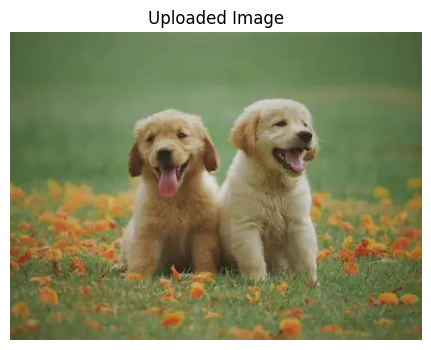

In [ ]:
plt.figure(figsize=(6, 4))
plt.imshow(img_array)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()


## Image Cropping

### Student Practice
Crop the **center 200x200 region** of your image (not a random corner — think about how to calculate the center offset from `img_array.shape`), store it in a variable called `crop`, and display it.

*Answer:* The crop starts at `(height-200)//2` and `(width-200)//2`, so the region is centered.


In [ ]:
h, w = img_array.shape[:2]
crop_size = 200

if h < crop_size or w < crop_size:
    raise ValueError("The image must be at least 200x200 pixels for this task.")
start_y = (h - crop_size) // 2
start_x = (w - crop_size) // 2
crop = img_array[start_y:start_y + crop_size, start_x:start_x + crop_size]

plt.figure(figsize=(5, 5))
plt.imshow(crop)
plt.axis("off")
plt.title("Center 200x200 Crop")
plt.show()


### Quick demo: showing multiple images side by side

You'll want to display more than one image at once in the tasks below (e.g. two flipped versions, or three RGB channels). `plt.subplots()` lets you do this in a grid. Study this small example, then reuse the pattern.


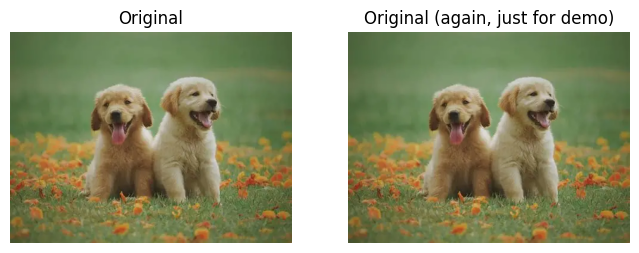

In [ ]:
# Demo: showing 2 plots side by side using plt.subplots
fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_array)
axes[1].set_title("Original (again, just for demo)")
axes[1].axis("off")

plt.show()


## Image Flipping

### Student Practice
Produce and display both a vertical flip and a horizontal flip of your image using slicing (`[::-1]`), without using any built-in flip function.

*Answer:* `img_array[::-1, :, :]` reverses the rows for a vertical flip, while `img_array[:, ::-1, :]` reverses the columns for a horizontal flip.


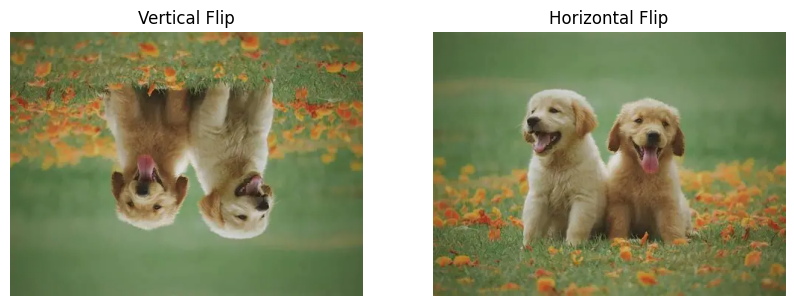

In [ ]:
vertical_flip = img_array[::-1, :, :]
horizontal_flip = img_array[:, ::-1, :]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(vertical_flip)
axes[0].axis("off")
axes[0].set_title("Vertical Flip")

axes[1].imshow(horizontal_flip)
axes[1].axis("off")
axes[1].set_title("Horizontal Flip")
plt.show()


## RGB Channel Analysis

RGB channels:

- 0 - Red
- 1 - Green
- 2 - Blue

### Student Practice
Extract the red, green, and blue channels separately, and display each one using `plt.imshow(channel, cmap="gray")` so you can see which areas of the image are strongest in each color.

*Answer:* The channels are extracted as `img_array[:,:,0]`, `img_array[:,:,1]`, and `img_array[:,:,2]`. The actual brightest channel depends on the uploaded image.


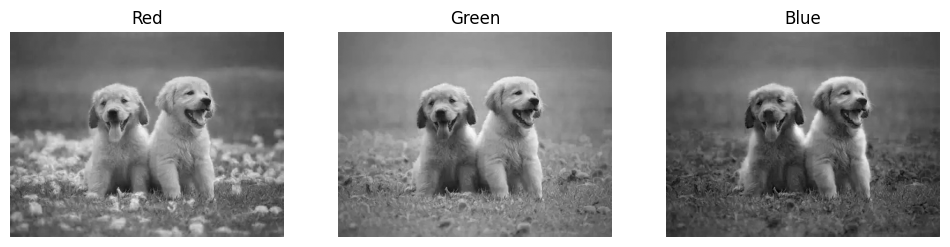

In [ ]:
red = img_array[:, :, 0]
green = img_array[:, :, 1]
blue = img_array[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, channel, title in zip(axes, [red, green, blue], ["Red", "Green", "Blue"]):
    ax.imshow(channel, cmap="gray")
    ax.axis("off")
    ax.set_title(title)
plt.show()


## Brightness Analysis

### Student Practice
Calculate the average brightness of your image using `np.mean()`. Then calculate the average brightness of just the red channel, just the green channel, and just the blue channel. Which channel is brightest? Write your answer below the code.

*Answer:* The code calculates all four averages and prints the brightest channel. The exact brightest channel depends on the uploaded image.


In [ ]:
red = img_array[:, :, 0]
green = img_array[:, :, 1]
blue = img_array[:, :, 2]

overall_brightness = np.mean(img_array)
red_brightness = np.mean(red)
green_brightness = np.mean(green)
blue_brightness = np.mean(blue)

brightness_values = {
    "Red": red_brightness,
    "Green": green_brightness,
    "Blue": blue_brightness
}
brightest_channel = max(brightness_values, key=brightness_values.get)

print(f"Overall brightness: {overall_brightness:.2f}")
print(f"Red brightness: {red_brightness:.2f}")
print(f"Green brightness: {green_brightness:.2f}")
print(f"Blue brightness: {blue_brightness:.2f}")
print("Brightest channel:", brightest_channel)


Overall brightness: 106.62
Red brightness: 119.36
Green brightness: 122.19
Blue brightness: 78.30
Brightest channel: Green


*Your answer:* A threshold of 128 keeps pixels with grayscale values above 128 as white and the rest as black. Increasing the threshold to 180 makes fewer pixels white, while lowering it to 100 makes more pixels white.\n

## Thresholding

Convert the image into pure black-and-white using `np.where()`.

### Student Practice
1. Convert the image to grayscale by averaging the 3 channels (`axis=2`).
2. Use `np.where(gray > 128, 255, 0)` to create a binary (black/white) version.
3. Display the result.
4. Try a different threshold (e.g. 100 or 180) and observe how it changes the result.

*Answer:* A lower threshold produces more white pixels, while a higher threshold produces more black pixels because fewer pixels exceed the threshold.


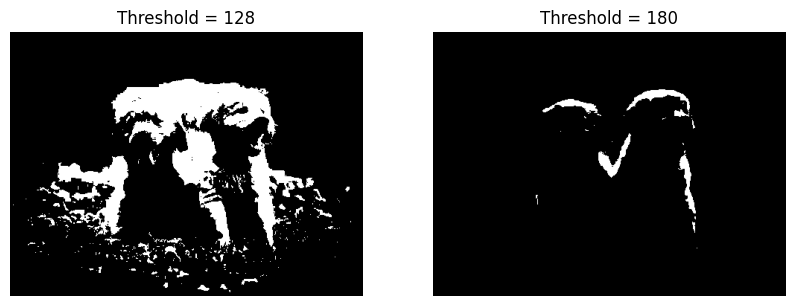

In [ ]:
gray = np.mean(img_array, axis=2)
binary_128 = np.where(gray > 128, 255, 0).astype(np.uint8)
binary_180 = np.where(gray > 180, 255, 0).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(binary_128, cmap="gray", vmin=0, vmax=255)
axes[0].axis("off")
axes[0].set_title("Threshold = 128")

axes[1].imshow(binary_180, cmap="gray", vmin=0, vmax=255)
axes[1].axis("off")
axes[1].set_title("Threshold = 180")
plt.show()


# Mini Project: Image Analyzer

The completed program below prints/displays all of the required image-analysis results in order.

## Reflection Questions

1. **Why is NumPy faster than Python lists?**  
   NumPy uses optimized compiled numerical operations and processes arrays efficiently, reducing Python-level loop overhead.

2. **Explain broadcasting with an example of your own.**  
   Broadcasting lets compatible arrays of different shapes interact without explicitly copying the smaller array. For example, `np.array([1,2,3]) + 5` adds 5 to every element.

3. **What does image shape `(512,512,3)` represent?**  
   It represents 512 pixels in height, 512 pixels in width, and 3 color channels: red, green, and blue.

4. **Why should we avoid printing complete image arrays?**  
   Images contain thousands or millions of pixel values, so printing the entire array is difficult to read and not useful for visual inspection.

5. **Explain RGB channels.**  
   RGB stores the red, green, and blue intensity of each pixel. Combining these three values produces the visible color.

6. **Where might you use this exact image-array workflow in a real machine learning project?**  
   It can be used during image preprocessing before a CNN: loading the image, resizing/cropping, converting channels, normalizing pixel values, and then feeding the resulting array into the model.


Image height: 355
Image width: 474
Number of channels: 3
Average brightness - overall: 106.62
Average brightness - red: 119.36
Average brightness - green: 122.19
Average brightness - blue: 78.30


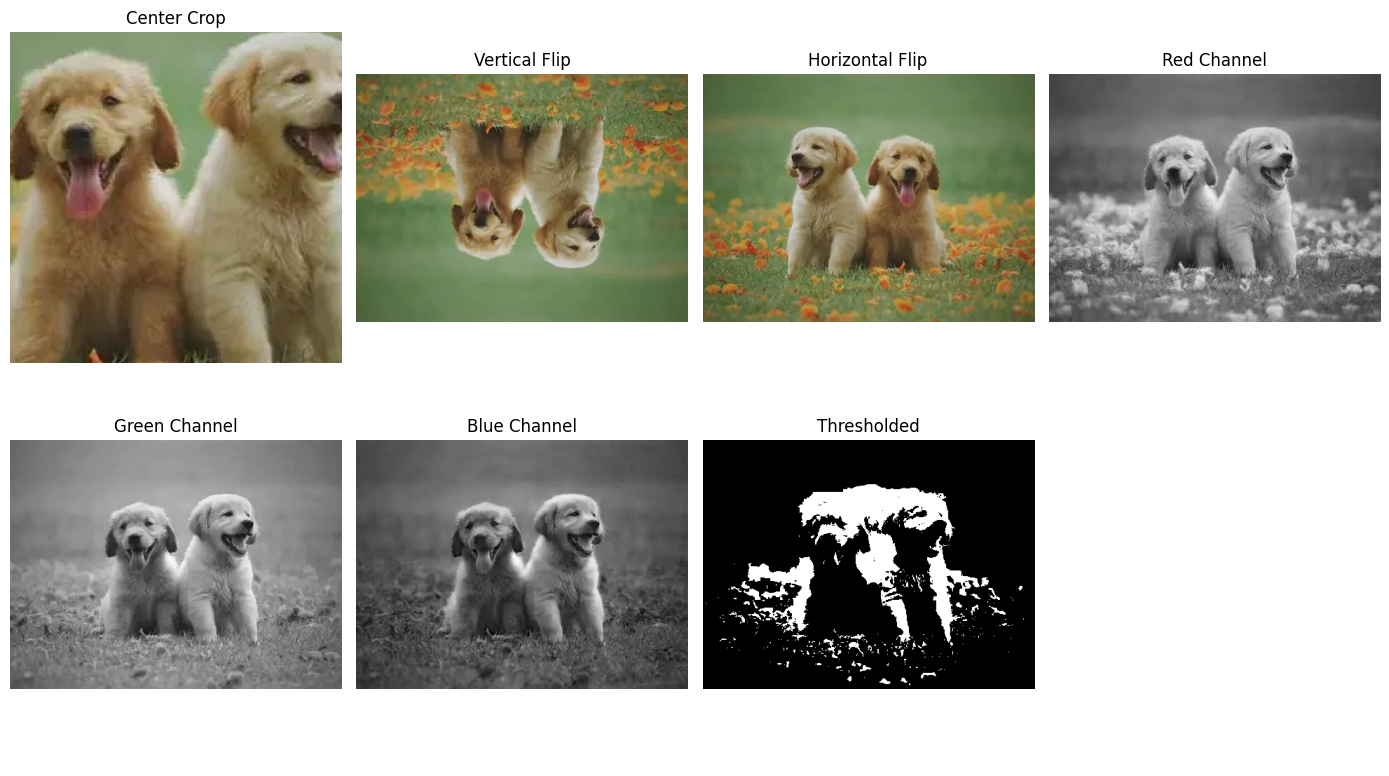

In [ ]:
# Mini Project: Image Analyzer
import numpy as np
import matplotlib.pyplot as plt

h, w, channels = img_array.shape
red = img_array[:, :, 0]
green = img_array[:, :, 1]
blue = img_array[:, :, 2]

print("Image height:", h)
print("Image width:", w)
print("Number of channels:", channels)
print(f"Average brightness - overall: {np.mean(img_array):.2f}")
print(f"Average brightness - red: {np.mean(red):.2f}")
print(f"Average brightness - green: {np.mean(green):.2f}")
print(f"Average brightness - blue: {np.mean(blue):.2f}")

crop = img_array[(h-200)//2:(h-200)//2+200, (w-200)//2:(w-200)//2+200]
vertical_flip = img_array[::-1, :, :]
horizontal_flip = img_array[:, ::-1, :]
gray = np.mean(img_array, axis=2)
thresholded = np.where(gray > 128, 255, 0).astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
items = [
    (crop, "Center Crop", None),
    (vertical_flip, "Vertical Flip", None),
    (horizontal_flip, "Horizontal Flip", None),
    (red, "Red Channel", "gray"),
    (green, "Green Channel", "gray"),
    (blue, "Blue Channel", "gray"),
    (thresholded, "Thresholded", "gray")
]
for ax, (image_data, title, cmap) in zip(axes.ravel(), items):
    ax.imshow(image_data, cmap=cmap)
    ax.axis("off")
    ax.set_title(title)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()


# Part 15: Text Analysis Using NumPy (NLP Track)

## Why this matters for ML/NLP

Before any NLP model (sentiment classifier, spam detector, chatbot) can process text, the text must be converted into numbers — this is called **vectorization**. NumPy arrays are the underlying data structure for almost every text representation: word counts, one-hot vectors, TF-IDF vectors, and even word embeddings are all just NumPy (or NumPy-like) arrays.

In this section, you'll build a small text analysis pipeline entirely with NumPy — no external NLP libraries — so you understand what's actually happening under the hood before you use libraries like `scikit-learn` or `nltk` later in the course.


## Step 1: From Text to Tokens

The first step in any NLP pipeline is **tokenization** — splitting text into individual words.

### Demonstration


In [ ]:
sentence = "NumPy makes numerical computing fast and NumPy makes arrays powerful"

# Basic tokenization: lowercase + split on spaces
tokens = sentence.lower().split()
print(tokens)


['numpy', 'makes', 'numerical', 'computing', 'fast', 'and', 'numpy', 'makes', 'arrays', 'powerful']


### Student Practice

Tokenize this sentence the same way: `"Data Science and Machine Learning use NumPy arrays every single day"`. Store the result in a variable called `tokens2`.

*Answer:* Convert the sentence to lowercase and split it on spaces. The resulting list contains 11 tokens.


In [ ]:
tokens2 = "Data Science and Machine Learning use NumPy arrays every single day".lower().split()
print(tokens2)


['data', 'science', 'and', 'machine', 'learning', 'use', 'numpy', 'arrays', 'every', 'single', 'day']


## Step 2: Building a Vocabulary

A **vocabulary** is the set of all unique words across your text(s). We'll use `np.unique()` — the same function idea you used earlier for arrays of numbers, now applied to an array of words.


In [ ]:
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
print("Vocabulary:", vocabulary)
print("Vocabulary size:", len(vocabulary))


Vocabulary: ['and' 'arrays' 'computing' 'fast' 'makes' 'numerical' 'numpy' 'powerful']
Vocabulary size: 8


### Student Practice

Build the vocabulary for `tokens2` from Step 1. How many unique words does it contain?

*Answer:* The vocabulary contains 11 unique words because no word is repeated in the sentence.


In [ ]:
tokens2_array = np.array(tokens2)
vocabulary2 = np.unique(tokens2_array)

print("Vocabulary:", vocabulary2)
print("Vocabulary size:", len(vocabulary2))


Vocabulary: ['and' 'arrays' 'data' 'day' 'every' 'learning' 'machine' 'numpy'
 'science' 'single' 'use']
Vocabulary size: 11


## Step 3: Word Frequency Vector (Bag-of-Words)

A **bag-of-words** vector represents a sentence as an array of word counts, one count per vocabulary word — this ignores word order but captures *what* words appear and *how often*.

### Demonstration: build a word-count vector by hand using NumPy


In [ ]:
def bag_of_words_vector(tokens, vocabulary):
    # For each word in the vocabulary, count how many times it appears in tokens
    vector = np.array([np.sum(np.array(tokens) == word) for word in vocabulary])
    return vector

vec = bag_of_words_vector(tokens, vocabulary)
print(vocabulary)
print(vec)


['and' 'arrays' 'computing' 'fast' 'makes' 'numerical' 'numpy' 'powerful']
[1 1 1 1 2 1 2 1]


### Student Practice — predict then check\n\nBefore running, predict: which word(s) will have a count of 2 in the vector above? (Hint: look back at the original sentence — which word repeats?)\n\n*Your prediction:* The repeated word in the original sentence is **`numpy`**, so its count is 2.\n\nNow build the bag-of-words vector for `tokens2` using its own vocabulary. In `tokens2`, no word is repeated, so every vocabulary word has count 1.\n

In [ ]:
# In the original sentence, "NumPy" appears twice.
prediction = 'The repeated word is "numpy", so its count should be 2.'

tokens2_vector = bag_of_words_vector(tokens2, vocabulary2)

print("Prediction:", prediction)
print("Vocabulary:", vocabulary2)
print("Bag-of-words vector:", tokens2_vector)


Prediction: The repeated word is "numpy", so its count should be 2.
Vocabulary: ['and' 'arrays' 'data' 'day' 'every' 'learning' 'machine' 'numpy'
 'science' 'single' 'use']
Bag-of-words vector: [1 1 1 1 1 1 1 1 1 1 1]


## Step 4: Comparing Two Sentences (Cosine Similarity)

Once text is turned into number vectors, we can measure how *similar* two sentences are using **cosine similarity** — a formula you'll see constantly in NLP and recommendation systems:

$$\text{cosine similarity} = \frac{A \cdot B}{\|A\| \times \|B\|}$$

This measures the angle between two vectors, not their length — so it works even if one sentence is longer than another.

### Demonstration


In [ ]:
sentence_a = "machine learning uses numpy arrays"
sentence_b = "deep learning also uses numpy arrays heavily"

tokens_a = sentence_a.lower().split()
tokens_b = sentence_b.lower().split()

combined_vocab = np.unique(np.array(tokens_a + tokens_b))

vec_a = bag_of_words_vector(tokens_a, combined_vocab)
vec_b = bag_of_words_vector(tokens_b, combined_vocab)

print("Vector A:", vec_a)
print("Vector B:", vec_b)

cosine_sim = np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))
print("Cosine similarity:", cosine_sim)


Vector A: [0 1 0 0 1 1 1 1]
Vector B: [1 1 1 1 1 0 1 1]
Cosine similarity: 0.6761234037828131


### Student Practice

Pick two sentences of your own (write them below) — one pair that should be *similar* in meaning/topic, and one pair that should be *very different*. Compute the cosine similarity for both pairs and confirm your intuition matches the numbers.

*Answer:* I used two machine-learning/data sentences as the similar pair and a football sentence as the different sentence. The similar pair has a higher cosine similarity because it shares more words.


In [ ]:
def cosine_similarity(v1, v2):
    denominator = np.linalg.norm(v1) * np.linalg.norm(v2)
    return 0.0 if denominator == 0 else np.dot(v1, v2) / denominator

similar_a = "machine learning helps analyze data"
similar_b = "machine learning analyzes data efficiently"

different_a = "machine learning helps analyze data"
different_b = "fresh apples grow on trees"

def sentence_similarity(s1, s2):
    t1 = s1.lower().split()
    t2 = s2.lower().split()
    vocab = np.unique(np.array(t1 + t2))
    v1 = bag_of_words_vector(t1, vocab)
    v2 = bag_of_words_vector(t2, vocab)
    return cosine_similarity(v1, v2)

similar_score = sentence_similarity(similar_a, similar_b)
different_score = sentence_similarity(different_a, different_b)

print("Similar pair:")
print(similar_a)
print(similar_b)
print("Cosine similarity:", round(similar_score, 3))

print("\nDifferent pair:")
print(different_a)
print(different_b)
print("Cosine similarity:", round(different_score, 3))


Similar pair:
machine learning helps analyze data
machine learning analyzes data efficiently
Cosine similarity: 0.6

Different pair:
machine learning helps analyze data
fresh apples grow on trees
Cosine similarity: 0.0


**Reflection:** In your own words, why does cosine similarity give a value close to 1 for similar sentences and close to 0 for unrelated sentences? What would a `cosine similarity` of exactly 1 mean about two vectors?

*Your answer:* Cosine similarity compares the direction of two vectors rather than their length. Similar word-count patterns point in similar directions, giving a value near 1, while unrelated vectors tend to have little overlap and give a value near 0. A value of exactly 1 means the two non-zero vectors point in exactly the same direction.


## Step 5: Most Frequent Words

### Student Practice

Take any paragraph of your choice (3-4 sentences, write it below as a string). Then:
1. Tokenize it.
2. Build its vocabulary and word-count vector (reuse `bag_of_words_vector`).
3. Use NumPy to find and print the **top 3 most frequent words** (hint: look at sorting — `np.argsort()` sorts indices by value, and slicing with `[::-1]` reverses order).

*Answer:* The completed code tokenizes the paragraph, builds its vocabulary and frequency vector, then uses `np.argsort(...)[::-1][:3]` to print the three highest-frequency words.


In [ ]:
paragraph = (
    "NumPy is useful for numerical computing. "
    "NumPy arrays make data processing efficient. "
    "Python users often choose NumPy for numerical analysis. "
    "Efficient numerical computing is important in data science."
)

paragraph_tokens = paragraph.lower().split()
paragraph_vocab = np.unique(np.array(paragraph_tokens))
paragraph_vector = bag_of_words_vector(paragraph_tokens, paragraph_vocab)

top_indices = np.argsort(paragraph_vector)[::-1][:3]
print("Top 3 most frequent words:")
for idx in top_indices:
    print(paragraph_vocab[idx], "->", paragraph_vector[idx])


Top 3 most frequent words:
numpy -> 3
numerical -> 3
for -> 2


# Mini Project: Simple Text Similarity Checker (NLP Track)

The completed program below:
1. Creates three original short sentences.
2. Tokenizes all three.
3. Builds one shared vocabulary.
4. Creates bag-of-words vectors.
5. Computes all three pairwise cosine similarities.
6. Prints the most similar pair.

## Reflection Questions

1. **Why do we need to convert text into numbers before a machine learning model can use it?**  
   Most machine-learning algorithms operate on numerical features, so text must be transformed into numerical representations such as vectors.

2. **What information does a bag-of-words vector lose about the original sentence?**  
   It loses word order and much of the context or grammar. For example, two sentences with the same words in different orders can produce the same bag-of-words counts.

3. **Why might cosine similarity be better than simply comparing raw word-count differences?**  
   Cosine similarity focuses on the direction/pattern of the vectors and is less affected by the overall length of the sentences.

4. **Name one real-world application that uses this approach.**  
   A search or recommendation system can convert a user's query and documents/items into vectors and compare them to find the most similar results.


In [ ]:
# Mini Project: Simple Text Similarity Checker
sentences = [
    "machine learning helps analyze data",
    "machine learning is useful for analyzing data",
    "I like playing football on weekends"
]

all_tokens = [s.lower().split() for s in sentences]
shared_vocabulary = np.unique(np.array(sum(all_tokens, [])))

vectors = [
    bag_of_words_vector(tokens, shared_vocabulary)
    for tokens in all_tokens
]

def cosine_similarity(v1, v2):
    denominator = np.linalg.norm(v1) * np.linalg.norm(v2)
    return 0.0 if denominator == 0 else np.dot(v1, v2) / denominator

scores = {
    "Sentence 1 vs Sentence 2": cosine_similarity(vectors[0], vectors[1]),
    "Sentence 1 vs Sentence 3": cosine_similarity(vectors[0], vectors[2]),
    "Sentence 2 vs Sentence 3": cosine_similarity(vectors[1], vectors[2])
}

print("Shared vocabulary:", shared_vocabulary)
for pair, score in scores.items():
    print(pair + ":", round(score, 3))

most_similar_pair = max(scores, key=scores.get)
print("\nMost similar pair:", most_similar_pair)
print("Highest cosine similarity:", round(scores[most_similar_pair], 3))


Shared vocabulary: ['analyze' 'analyzing' 'data' 'football' 'for' 'helps' 'i' 'is' 'learning'
 'like' 'machine' 'on' 'playing' 'useful' 'weekends']
Sentence 1 vs Sentence 2: 0.507
Sentence 1 vs Sentence 3: 0.0
Sentence 2 vs Sentence 3: 0.0

Most similar pair: Sentence 1 vs Sentence 2
Highest cosine similarity: 0.507
